# Lab 01: Big Data Systems and Digital Twins — An Overview

A real city pours out observations of temperature, wind and radiation every
moment. If a **virtual city** updates its state every time those observations
arrive, and then forecasts the future again — that is a **digital twin**. This
semester we will build that closed loop ourselves. Today we look at the whole
structure at once, and **complete a miniature of the entire semester in a
40-line simulation**.

> **Preview of the running example:** the 2D temperature field we build today
> comes back in Weeks 10–13 as serial → OpenMP → MPI → JAX → observation update.
> Today's goal is to be convinced *by numbers* of why that journey is worth it.

## Learning Objectives

By the end of this lab you will be able to:

- Explain the **closed-loop structure** of a digital twin (observation → state
  update → forecast) in your own words, and map it onto real systems such as
  DestinE and NOAA EODT.
- Draw a system diagram of the **five stages** of the end-of-semester pipeline,
  connected to the tools of each week (Spark, Xarray/Dask, OpenMP/MPI, JAX).
- Implement **persistence forecasting (M0)**, **open-loop simulation**, and the
  **observation-updated closed loop** on the same problem and compare them by RMSE.
- Understand the Kaggle competition's problem definition, evaluation metric
  (RMSE), milestones (M0→M4) and the score conversion formula.
- Estimate the **data volume** of real observational datasets and explain why
  distributed and parallel processing is needed.


In [1]:

%matplotlib inline
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 11
rng = np.random.default_rng(0)   # fixed seed for reproducibility
print("numpy", np.__version__)


numpy 2.3.3


---
## 1. What is a digital twin?

A **digital twin** is a virtual model paired with a real physical system and kept
continuously synchronized with it by observational data. What separates it from a
static simulation or a one-shot forecast is the **closed loop**:

| Component | Role |
|---|---|
| Physical twin | The real city / atmosphere — it generates observations |
| Virtual twin | The numerical model that advances the state |
| Observation feedback | When observations arrive, they **pull** the virtual state |
| Forecast & dashboard | The updated state is used to look ahead |

The point is not "we used an AI model", but that the system has a **structure in
which incoming observations update the state, which then forecasts the future
again**.

### Real systems

| System | Organization | What it twins |
|---|---|---|
| Destination Earth (DestinE) | ECMWF / EU | Earth's climate and weather (km scale) |
| Earth's Observation-based Digital Twin (EODT) | NOAA | Fused ocean–atmosphere observations |
| Our course project | Course410 | Urban thermal environment (temperature per grid cell) |


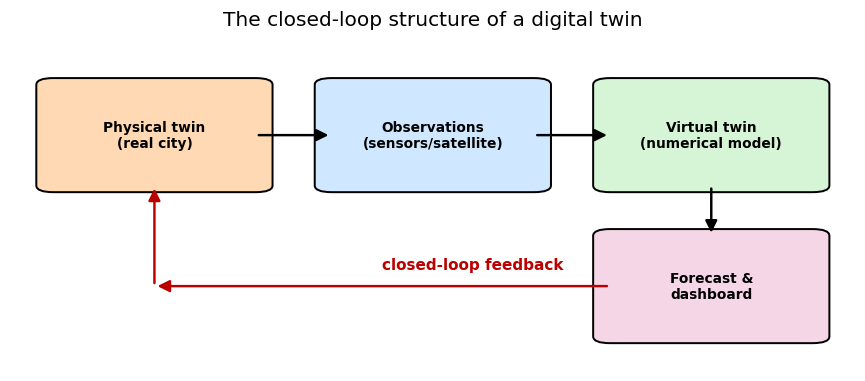

In [2]:

# Draw the closed-loop structure ourselves (pin the concept down in code).
def box(ax, xy, w, h, text, fc, fs=10):
    ax.add_patch(FancyBboxPatch(xy, w, h, boxstyle="round,pad=0.02",
                                fc=fc, ec="black", lw=1.3))
    ax.text(xy[0] + w/2, xy[1] + h/2, text, ha="center", va="center",
            fontsize=fs, weight="bold")

def arrow(ax, p0, p1, color="black", style="-|>"):
    ax.add_patch(FancyArrowPatch(p0, p1, arrowstyle=style, mutation_scale=16,
                                 lw=1.6, color=color))

fig, ax = plt.subplots(figsize=(8, 3.6))
box(ax, (0.05, 0.55), 0.24, 0.30, "Physical twin\n(real city)", "#ffd9b3", fs=9)
box(ax, (0.38, 0.55), 0.24, 0.30, "Observations\n(sensors/satellite)", "#cfe8ff", fs=9)
box(ax, (0.71, 0.55), 0.24, 0.30, "Virtual twin\n(numerical model)", "#d6f5d6", fs=9)
box(ax, (0.71, 0.10), 0.24, 0.30, "Forecast &\ndashboard", "#f5d6e6", fs=9)

arrow(ax, (0.29, 0.70), (0.38, 0.70))          # reality -> observations
arrow(ax, (0.62, 0.70), (0.71, 0.70))          # observations -> model (state update)
arrow(ax, (0.83, 0.55), (0.83, 0.40))          # model -> forecast
arrow(ax, (0.71, 0.25), (0.17, 0.25), "#b00")  # forecast -> compare with reality
arrow(ax, (0.17, 0.25), (0.17, 0.55), "#b00")
ax.text(0.44, 0.30, "closed-loop feedback", color="#b00", fontsize=10, weight="bold")
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis("off")
ax.set_title("The closed-loop structure of a digital twin")
plt.tight_layout()


> **Observe:** without the red arrows (observation → state update → compare with
> reality again) this is just an ordinary simulation. Whether that feedback loop
> exists or not is exactly what will split the RMSE numbers in the second half of
> today's lab.

---
## 2. The five stages of the end-of-semester pipeline

The mandatory pipeline we will complete over 15 weeks looks like this:

```
ingest observations -> align in space-time -> forecast state -> update with observations -> dashboard
```

Each stage maps to specific tools and weeks:

| Stage | Tools | Weeks |
|---|---|---|
| ① Ingest observations | OpenAPI, satellites (GEE/COG/STAC) | 5, 9 |
| ② Align & aggregate in space-time | Spark, Xarray/Dask, NetCDF/Zarr | 3–4, 6–7 |
| ③ Forecast state | Heat-diffusion simulator (serial→OpenMP→MPI→JAX) | 10–12 |
| ④ Update with observations | Nudging / state estimation | 13 |
| ⑤ Dashboard & analysis | Integration, ablation | 14–15 |


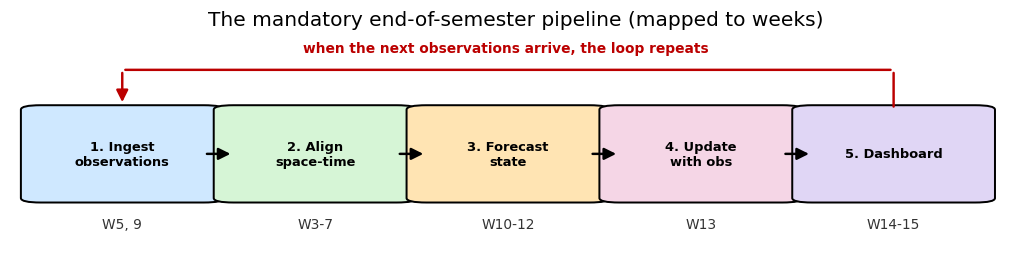

In [3]:

# Visualize the five-stage pipeline as a horizontal flow.
stages = ["1. Ingest\nobservations", "2. Align\nspace-time", "3. Forecast\nstate",
          "4. Update\nwith obs", "5. Dashboard"]
weeks  = ["W5, 9", "W3-7", "W10-12", "W13", "W14-15"]
colors = ["#cfe8ff", "#d6f5d6", "#ffe4b3", "#f5d6e6", "#e0d6f5"]

fig, ax = plt.subplots(figsize=(9.5, 2.6))
x, w = 0.03, 0.165
centers = []
for s, wk, c in zip(stages, weeks, colors):
    box(ax, (x, 0.28), w, 0.40, s, c, fs=8.5)
    ax.text(x + w/2, 0.16, wk, ha="center", va="center", fontsize=9, color="#333")
    if x > 0.03:
        arrow(ax, (x - 0.03, 0.48), (x, 0.48))
    centers.append(x + w/2)
    x += w + 0.03
# Closed loop: the dashboard feeds back into ingestion (routed above the boxes)
arrow(ax, (centers[-1], 0.68), (centers[-1], 0.86), "#b00", style="-")
arrow(ax, (centers[-1], 0.86), (centers[0], 0.86), "#b00", style="-")
arrow(ax, (centers[0], 0.86), (centers[0], 0.70), "#b00")
ax.text(0.5, 0.94, "when the next observations arrive, the loop repeats",
        ha="center", color="#b00", fontsize=9, weight="bold")
ax.set_xlim(0, 1.02); ax.set_ylim(0, 1.02); ax.axis("off")
ax.set_title("The mandatory end-of-semester pipeline (mapped to weeks)")
plt.tight_layout()


> **Observe:** today's lab walks through **all five stages, at a very small
> scale**. Section 3 covers ①② (observations), Sections 4–5 cover ③ (forecast),
> Section 6 covers ④ (update), and Section 7 covers ⑤ (evaluation) — each in a few
> lines. The rest of the semester is the process of growing each piece into
> something "large-scale, reproducible and parallel".

---
## 3. Making observations — a synthetic urban temperature field

Real data starts in Week 5. Today we build a **synthetic "real city"** so that we
can experiment with the twin while knowing the ground truth. Treat the city as an
$N\times N$ grid and assume the temperature of each cell follows the **heat
diffusion equation**:

$$ \frac{\partial T}{\partial t} = \alpha\,\nabla^2 T + f(x, y, t) $$

- $\alpha$: thermal diffusivity
- $f$: external heat input (the time-varying urban heat island — hot by day,
  cooling at night)

We march it with an explicit scheme, and we must respect the **stability
condition** $\alpha\,\Delta t / \Delta x^2 \le 1/4$ (revisited in Week 10).


In [4]:

# --- Grid and discretization parameters (the same notation returns in Weeks 10-13) ---
N   = 50            # cells per side
dx  = 1.0           # grid spacing dx (grid units)
dt  = 1.0           # time step dt
alpha = 0.20        # thermal diffusivity alpha

# 5-point Laplacian (insulated boundary: Neumann approximated by edge replication)
def laplacian(T):
    Tp = np.pad(T, 1, mode="edge")
    return (Tp[2:, 1:-1] + Tp[:-2, 1:-1] +
            Tp[1:-1, 2:] + Tp[1:-1, :-2] - 4.0 * T) / dx**2

def diffuse(T):
    return T + alpha * dt * laplacian(T)

cfl = alpha * dt / dx**2
print(f"diffusion CFL number  α·Δt/Δx² = {cfl:.3f}   (stable if <= 0.25 -> {'OK' if cfl <= 0.25 else 'UNSTABLE'})")


diffusion CFL number  α·Δt/Δx² = 0.200   (stable if <= 0.25 -> OK)


initial temperature range: 15.0 ~ 23.0 °C


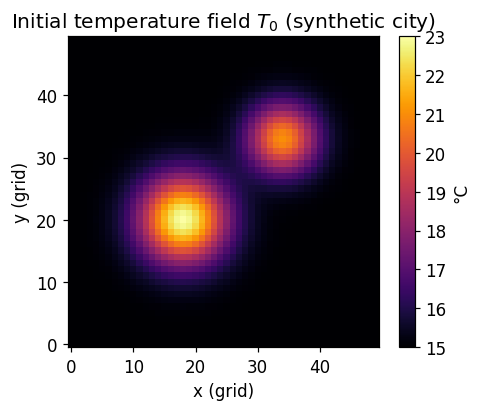

In [5]:

# --- Initial temperature field: two urban heat islands on a background ---
yy, xx = np.mgrid[0:N, 0:N]
def hotspot(cx, cy, amp, sig):
    return amp * np.exp(-((xx - cx)**2 + (yy - cy)**2) / (2 * sig**2))

T0 = 15.0 + hotspot(18, 20, 8.0, 5.0) + hotspot(34, 33, 6.0, 4.0)
print(f"initial temperature range: {T0.min():.1f} ~ {T0.max():.1f} °C")

fig, ax = plt.subplots(figsize=(4.6, 3.8))
im = ax.imshow(T0, origin="lower", cmap="inferno")
ax.set_title("Initial temperature field $T_0$ (synthetic city)")
ax.set_xlabel("x (grid)"); ax.set_ylabel("y (grid)")
fig.colorbar(im, ax=ax, label="°C")
plt.tight_layout()


In [6]:

# --- The "real city" heat input f(x,y,t): a moving heat island + a diurnal cycle ---
P = 48                       # diurnal period (imagine 48 steps = one day)
def forcing(t):
    # the heat source centre travels in a circle (movement of urban activity)
    cx = 25 + 10 * np.cos(2 * np.pi * t / (2 * P))
    cy = 25 + 10 * np.sin(2 * np.pi * t / (2 * P))
    diurnal = 0.5 + 0.5 * np.sin(2 * np.pi * t / P)   # day / night
    return 1.2 * diurnal * np.exp(-((xx - cx)**2 + (yy - cy)**2) / (2 * 4.0**2))

# March the real city forward: diffusion + the unknown heat input
def truth_step(T, t):
    return diffuse(T) + dt * forcing(t)

STEPS = 200
truth = np.empty((STEPS + 1, N, N))
truth[0] = T0
for t in range(STEPS):
    truth[t + 1] = truth_step(truth[t], t)

print(f"real city marched {STEPS} steps. final temperature range "
      f"{truth[-1].min():.1f} ~ {truth[-1].max():.1f} °C")


real city marched 200 steps. final temperature range 15.1 ~ 33.9 °C


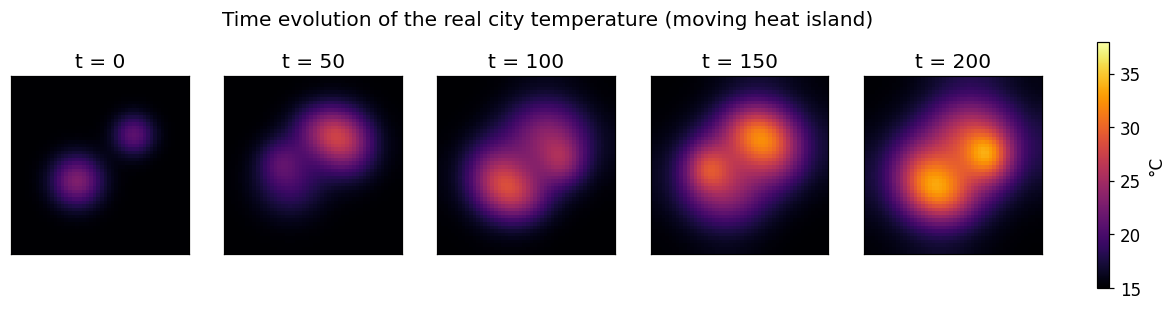

In [7]:

# A few snapshots of the real city
snaps = [0, 50, 100, 150, 200]
fig, axes = plt.subplots(1, len(snaps), figsize=(13, 2.9))
vmin, vmax = truth.min(), truth.max()
for ax, t in zip(axes, snaps):
    im = ax.imshow(truth[t], origin="lower", cmap="inferno", vmin=vmin, vmax=vmax)
    ax.set_title(f"t = {t}")
    ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(im, ax=axes, label="°C", fraction=0.02)
fig.suptitle("Time evolution of the real city temperature (moving heat island)");


> **Observe:** the CFL number is 0.20 (≤ 0.25), so the simulation stays stable.
> The real city both spreads out by diffusion and keeps fluctuating because of the
> diurnal heat source travelling in a circle. **Our model knows nothing about that
> heat source $f$** — and that is where the limits of open-loop forecasting, and
> the need for observational updates, come from.

---
## 4. Forecast baseline — persistence (a preview of M0)

The simplest forecast: assume **"the current state stays as it is."** This is
called **persistence**, and it is the baseline for the first milestone of the
Kaggle competition, **M0** (due in Week 5).

$$ \hat{T}(t + k) = T(t) $$

It does not look clever, but at short lead times it is surprisingly strong — which
is exactly why it becomes the minimum bar every model has to clear.


In [8]:

# persistence: copy the state at time t0 into the future as the forecast.
def rmse(a, b):
    return float(np.sqrt(np.mean((a - b)**2)))

t0 = 100
horizons = [1, 3, 6, 12, 24]
print(f"{'lead time (steps)':>18} | {'persistence RMSE (°C)':>26}")
print("-" * 48)
for k in horizons:
    err = rmse(truth[t0], truth[t0 + k])   # forecast = truth[t0], target = truth[t0+k]
    print(f"{k:>18} | {err:>26.3f}")


 lead time (steps) |      persistence RMSE (°C)
------------------------------------------------
                 1 |                      0.119
                 3 |                      0.377
                 6 |                      0.794
                12 |                      1.586
                24 |                      2.281


> **Observe:** the longer the lead time, the larger the persistence error. One
> step ahead is fine; 24 steps ahead misses badly. The real competition task is
> also "temperature 1–6 hours ahead", so at short lead times persistence is a
> formidable opponent.

---
## 5. Open-loop simulation — why the model alone is not enough

Now we forecast by running a **numerical model**. But our model only knows about
heat diffusion — it **does not know the unknown heat input $f$**. It starts from
the same initial state as the real city, but if it marches on alone with no
observations (= open loop), it drifts further from the truth as time passes.


In [9]:

# The model only knows diffusion (no forcing term). Marching with no observations = open loop.
def model_step(T):
    return diffuse(T)

open_loop = np.empty_like(truth)
open_loop[0] = T0.copy()
for t in range(STEPS):
    open_loop[t + 1] = model_step(open_loop[t])

rmse_open = np.array([rmse(open_loop[t], truth[t]) for t in range(STEPS + 1)])
print(f"open-loop RMSE:  initial {rmse_open[0]:.3f} -> final {rmse_open[-1]:.3f} °C")


open-loop RMSE:  initial 0.000 -> final 6.756 °C


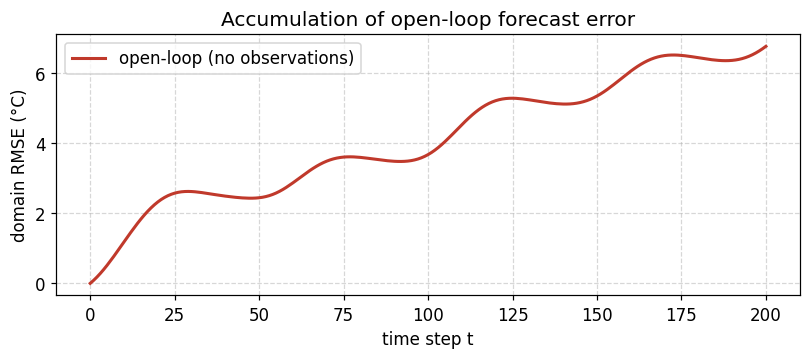

In [10]:

fig, ax = plt.subplots(figsize=(7.5, 3.4))
ax.plot(rmse_open, lw=2, color="#c0392b", label="open-loop (no observations)")
ax.set_xlabel("time step t"); ax.set_ylabel("domain RMSE (°C)")
ax.set_title("Accumulation of open-loop forecast error")
ax.grid(True, ls="--", alpha=0.5); ax.legend()
plt.tight_layout()


> **Observe:** the open-loop error grows monotonically with time, because the
> effect of the heat input $f$ that the model misses keeps piling up. **However
> accurate a physical model is, it can never contain every process of reality** —
> and that is precisely where observations come in as the relief pitcher.

---
## 6. Closing the loop — updating the state with observations (one line of nudging)

Here is the heart of it. Suppose **sensors** scattered around the city observe the
temperature at a few grid points (with noise). At every step, after marching the
model forward, we **pull the state at the observed points toward the observed
values by a factor $\kappa$**. This is **nudging**, and it is the heart of today's
lab:

$$ T \leftarrow T + \kappa\,(y_{\text{obs}} - T)\quad\text{(at observed points only)} $$

With $\kappa=0$ this is open-loop; with $\kappa=1$ we believe the observations
completely. In Week 13 (M3) we will experiment properly with update frequency and
strength. Today we only look at **how much one line changes the RMSE**.


In [11]:

# Fixed sensor locations (25 of them around the city), observation noise sigma_obs
n_sensors = 25
sy = rng.integers(0, N, n_sensors)
sx = rng.integers(0, N, n_sensors)
sigma_obs = 0.3          # observation noise (°C)
kappa = 0.5              # nudging strength

def observe(t):
    # observe the real city at the sensor points, with noise
    return truth[t, sy, sx] + rng.normal(0, sigma_obs, n_sensors)

# Closed loop: march the model, then pull the observed points toward the observations
closed = np.empty_like(truth)
closed[0] = T0.copy()
for t in range(STEPS):
    T = model_step(closed[t])
    y = observe(t + 1)
    T[sy, sx] += kappa * (y - T[sy, sx])   # <- the one line of nudging
    closed[t + 1] = T

rmse_closed = np.array([rmse(closed[t], truth[t]) for t in range(STEPS + 1)])
print(f"closed-loop RMSE: initial {rmse_closed[0]:.3f} -> final {rmse_closed[-1]:.3f} °C")
print(f"final improvement: {(1 - rmse_closed[-1] / rmse_open[-1]) * 100:.1f}%  "
      f"(open {rmse_open[-1]:.3f} -> closed {rmse_closed[-1]:.3f})")


closed-loop RMSE: initial 0.000 -> final 5.340 °C
final improvement: 21.0%  (open 6.756 -> closed 5.340)


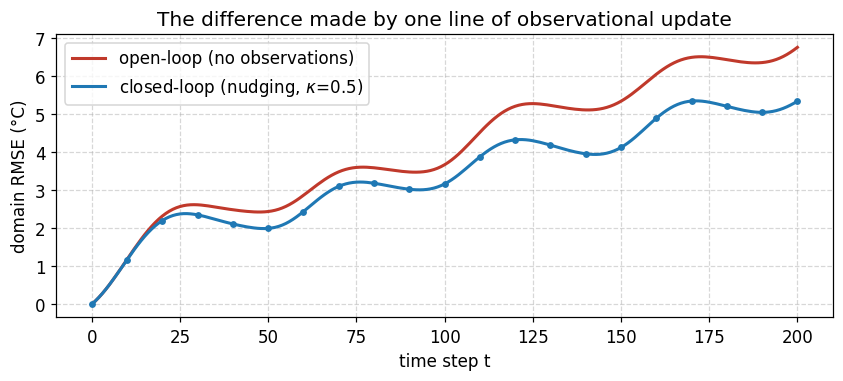

In [12]:

fig, ax = plt.subplots(figsize=(7.8, 3.6))
ax.plot(rmse_open,   lw=2, color="#c0392b", label="open-loop (no observations)")
ax.plot(rmse_closed, lw=2, color="#1f78b4", label=f"closed-loop (nudging, $\\kappa$={kappa})")
ax.scatter(range(0, STEPS + 1, 10), rmse_closed[::10], s=12, color="#1f78b4", zorder=3)
ax.set_xlabel("time step t"); ax.set_ylabel("domain RMSE (°C)")
ax.set_title("The difference made by one line of observational update")
ax.grid(True, ls="--", alpha=0.5); ax.legend()
plt.tight_layout()


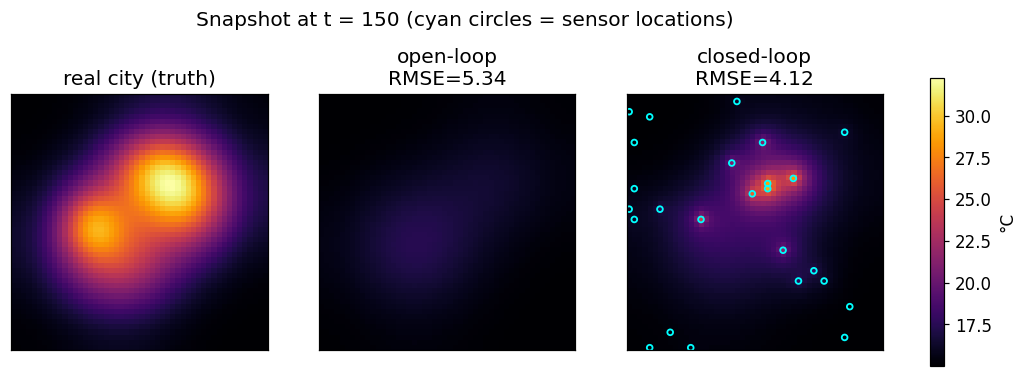

In [13]:

# Truth / open-loop / closed-loop side by side at the same instant
t_show = 150
fields = [truth[t_show], open_loop[t_show], closed[t_show]]
titles = ["real city (truth)", f"open-loop\nRMSE={rmse_open[t_show]:.2f}",
          f"closed-loop\nRMSE={rmse_closed[t_show]:.2f}"]
vmin, vmax = truth[t_show].min(), truth[t_show].max()
fig, axes = plt.subplots(1, 3, figsize=(11, 3.4))
for ax, F, tt in zip(axes, fields, titles):
    im = ax.imshow(F, origin="lower", cmap="inferno", vmin=vmin, vmax=vmax)
    ax.set_title(tt); ax.set_xticks([]); ax.set_yticks([])
axes[2].scatter(sx, sy, s=14, facecolors="none", edgecolors="cyan", lw=1.2)
fig.colorbar(im, ax=axes, label="°C", fraction=0.02)
fig.suptitle(f"Snapshot at t = {t_show} (cyan circles = sensor locations)", y=1.06);


> **Observe:** **one line of nudging** against just 25 sensors dropped the final
> RMSE substantially (check the improvement printed above). In the snapshots the
> closed loop even catches up with the position of the real city's moving heat
> source — the observations filled in physics the model did not know.
> **This is why a digital twin beats a plain simulation, and it is the central
> claim of this course.**

---
## 7. The Kaggle competition — the problem we compete on

The evaluation axis of this semester is a **Kaggle Community Competition (private
leaderboard)**.

> Using the past 24 hours of weather observations and satellite features,
> **forecast the temperature 1–6 hours ahead for each grid cell**.

- **Metric:** RMSE (lower is better), 5 submissions per day
- **Data:** summer 2025 observations (frozen in August before the semester) —
  train / public / private

### Mandatory milestones

| Model | Content | Due |
|---|---|---|
| M0 | persistence / climatology baseline | Week 5 |
| M1 | observation-based ML model | Week 8 |
| M2 | simple physical simulator (MPI heat diffusion) | Week 11 |
| M3 | hybrid twin updated by observations | Week 13 |
| M4 | free-form model | Week 14 |

You are graded not on a single best score but on the **process of improvement and
analysis from M0 to M3**. The persistence (M0), open-loop and closed-loop models
we built today are miniatures of M0, M2 and M3.


In [14]:

# Treat the three methods as "submissions" and score them by the all-grid mean RMSE
# over continuous operation. (There are only 25 sensors, but as in the competition
# the scoring covers the entire city grid.)
warm, lead = 20, 6
def field_persistence(t):        # forecast = the state `lead` steps ago (all-grid persistence)
    return truth[t - lead]

board = {
    f"M0 persistence (lead {lead})":
        float(np.mean([rmse(field_persistence(t), truth[t]) for t in range(warm, STEPS + 1)])),
    "M2 open-loop sim":
        float(np.mean([rmse(open_loop[t], truth[t]) for t in range(warm, STEPS + 1)])),
    "M3 closed-loop twin":
        float(np.mean([rmse(closed[t], truth[t]) for t in range(warm, STEPS + 1)])),
}
print(f"{'submission':<28}{'all-grid mean RMSE':>22}")
print("-" * 50)
for name, e in sorted(board.items(), key=lambda kv: kv[1]):
    print(f"{name:<28}{e:>22.3f}")
imp = (1 - board['M3 closed-loop twin'] / board['M2 open-loop sim']) * 100
print(f"\neffect of the observational update (twin vs open-loop): {imp:.1f}% improvement")
print("note: persistence at short lead times is very strong -- the twin does not beat it yet.")


submission                      all-grid mean RMSE
--------------------------------------------------
M0 persistence (lead 6)                      0.484
M3 closed-loop twin                          3.673
M2 open-loop sim                             4.440

effect of the observational update (twin vs open-loop): 17.3% improvement
note: persistence at short lead times is very strong -- the twin does not beat it yet.


lead=1 persistence RMSE=0.083, lead=72 -> 3.168 => as the lead grows it converges to / is overtaken by the twin (3.673).


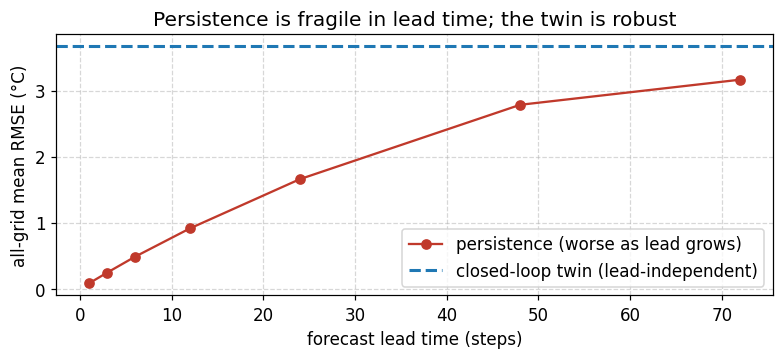

In [15]:

# Persistence degrades sharply as the lead time grows, while the error of a
# continuously updated twin is almost independent of lead time. Watch where the
# two curves head.
leads = [1, 3, 6, 12, 24, 48, 72]
per_by_lead = [float(np.mean([rmse(truth[t - L], truth[t]) for t in range(warm, STEPS + 1)]))
               for L in leads]
twin_level = board["M3 closed-loop twin"]

fig, ax = plt.subplots(figsize=(7.4, 3.4))
ax.plot(leads, per_by_lead, "o-", color="#c0392b",
        label="persistence (worse as lead grows)")
ax.axhline(twin_level, color="#1f78b4", lw=2, ls="--",
           label="closed-loop twin (lead-independent)")
ax.set_xlabel("forecast lead time (steps)"); ax.set_ylabel("all-grid mean RMSE (°C)")
ax.set_title("Persistence is fragile in lead time; the twin is robust")
ax.grid(True, ls="--", alpha=0.5); ax.legend()
plt.tight_layout()
print(f"lead=1 persistence RMSE={per_by_lead[0]:.3f}, lead=72 -> {per_by_lead[-1]:.3f} "
      f"=> as the lead grows it converges to / is overtaken by the twin ({twin_level:.3f}).")


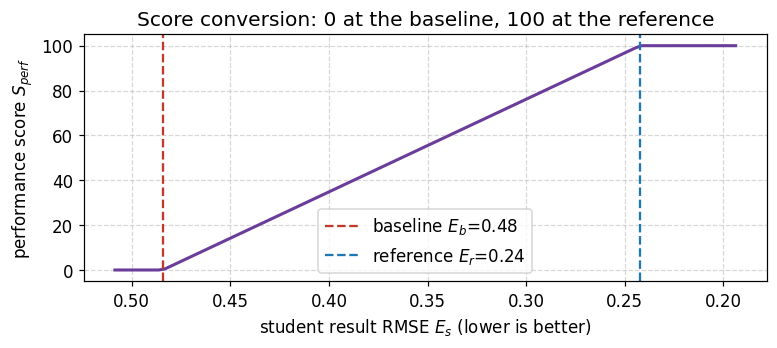

In [16]:

# Score conversion formula (curriculum section 4): based on improvement over the
# baseline, reaching 100 points at the reference. The reference must be *better*
# (lower RMSE) than the baseline to be meaningful, so we use an illustrative value.
def s_perf(E_s, E_b, E_r):
    return 100.0 * np.clip((E_b - E_s) / (E_b - E_r), 0.0, 1.0)

E_b = board[f"M0 persistence (lead {lead})"]   # baseline = M0
E_r = 0.5 * E_b                                # a hypothetical strong reference (instructor model)
E_grid = np.linspace(0.4 * E_b, 1.05 * E_b, 100)
scores = [s_perf(e, E_b, E_r) for e in E_grid]

fig, ax = plt.subplots(figsize=(7.2, 3.3))
ax.plot(E_grid, scores, lw=2, color="#6a3d9a")
ax.axvline(E_b, ls="--", color="#c0392b", label=f"baseline $E_b$={E_b:.2f}")
ax.axvline(E_r, ls="--", color="#1f78b4", label=f"reference $E_r$={E_r:.2f}")
ax.set_xlabel("student result RMSE $E_s$ (lower is better)")
ax.set_ylabel("performance score $S_{perf}$")
ax.set_title("Score conversion: 0 at the baseline, 100 at the reference")
ax.grid(True, ls="--", alpha=0.5); ax.legend()
ax.invert_xaxis()
plt.tight_layout()


> **Observe:** persistence is an extremely strong baseline at short lead times,
> so today's twin does **not** immediately beat it on all-grid RMSE — which is
> exactly why persistence is the bar that must be cleared (**M0**). Still, the
> observational update (1) clearly reduces the error relative to open-loop, and
> (2) does not collapse as the lead time grows (the two figures above). **The
> M0→M3 journey of this course is itself the process of finally overtaking a
> strong persistence baseline with physics + observations.** The score conversion
> formula rewards each step of that journey by scoring improvement over the
> baseline rather than rank.

---
## 8. A sense of big-data scale — why distributed and parallel processing?

Today's grid is a $50\times50$ toy run for 200 steps. How big is a real urban
thermal digital twin? Let us work out the rough scale and judge **whether a single
laptop could handle it**. That sense of scale is the answer to "why do we need
this tool?" from Spark in Week 3 through JAX in Week 12.


In [17]:

# Realistic scale estimates: high-resolution city grid x several variables x many times.
GB = 1024**3
scenarios = {
    "today's lab (50^2, 200 steps)":                        (50, 50, 1, 200),
    "city 1 km grid (1000^2, 1 var, hourly for 1 year)":    (1000, 1000, 1, 24 * 365),
    "multivariate city twin (2000^2, 8 vars, 1 year)":      (2000, 2000, 8, 24 * 365),
}
print(f"{'scenario':<52}{'cells':>16}{'size (float32)':>18}")
print("-" * 86)
sizes = {}
for name, (nx, ny, nv, nt) in scenarios.items():
    cells_n = nx * ny * nv * nt
    gb = cells_n * 4 / GB
    sizes[name] = gb
    print(f"{name:<52}{cells_n:>16,}{gb:>15.2f} GB")


scenario                                                       cells    size (float32)
--------------------------------------------------------------------------------------
today's lab (50^2, 200 steps)                                500,000           0.00 GB
city 1 km grid (1000^2, 1 var, hourly for 1 year)      8,760,000,000          32.63 GB
multivariate city twin (2000^2, 8 vars, 1 year)      280,320,000,000        1044.27 GB


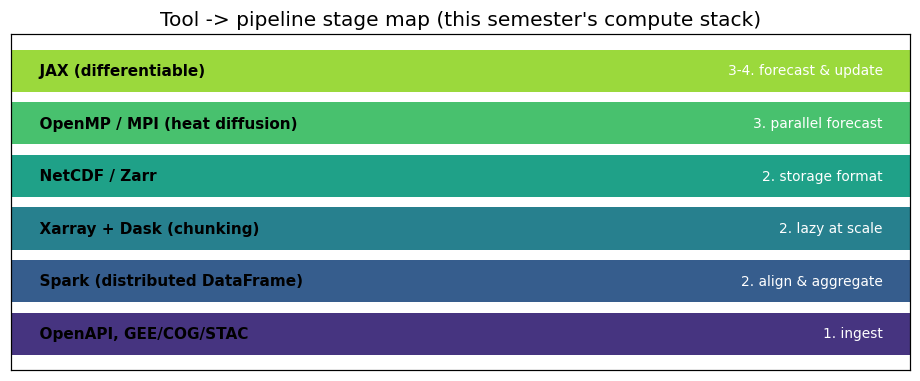

In [18]:

# A map of tools bridging the data layer (ingest, align) and the compute layer (forecast).
tools = {
    "OpenAPI, GEE/COG/STAC":         "1. ingest",
    "Spark (distributed DataFrame)": "2. align & aggregate",
    "Xarray + Dask (chunking)":      "2. lazy at scale",
    "NetCDF / Zarr":                 "2. storage format",
    "OpenMP / MPI (heat diffusion)": "3. parallel forecast",
    "JAX (differentiable)":          "3-4. forecast & update",
}
fig, ax = plt.subplots(figsize=(8.5, 3.6))
ax.barh(range(len(tools)), [1] * len(tools),
        color=plt.cm.viridis(np.linspace(0.15, 0.85, len(tools))))
for i, (t, stage) in enumerate(tools.items()):
    ax.text(0.02, i, f"  {t}", va="center", fontsize=10, weight="bold")
    ax.text(0.98, i, stage + "  ", va="center", ha="right", fontsize=9, color="white")
ax.set_yticks([]); ax.set_xticks([]); ax.set_xlim(0, 1)
ax.set_title("Tool -> pipeline stage map (this semester's compute stack)")
plt.tight_layout()


> **Observe:** a multivariate city twin reaches hundreds of GB and cannot be held
> in the memory of a single machine. That is why we need **distributed processing
> (Spark)**, **chunk-based lazy computation (Dask)**, **parallel simulation
> (OpenMP/MPI)** and **accelerated, differentiable computation (JAX)**. Every tool
> we learn this semester exists to run one of the five pipeline stages above "even
> at scale".

---
## 🔬 Exercises

The problems below build intuition by tweaking the mini twin we made today. A
working reference solution follows each one — try it yourself first, then compare.


**Exercise 1.** Vary the nudging strength $\kappa$ from 0 (open-loop) to 1 and
plot how the final RMSE changes. Is "believing the observations more strongly"
always better?


best kappa ~ 1.0, giving RMSE = 5.003 °C
If kappa is too large we swallow the observation noise as well, which can make things worse.


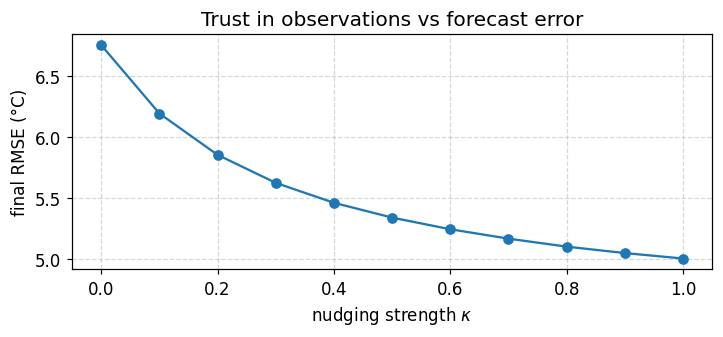

In [19]:

def run_closed(kappa):
    C = T0.copy()
    for t in range(STEPS):
        T = model_step(C)
        y = truth[t + 1, sy, sx] + rng.normal(0, sigma_obs, n_sensors)
        T[sy, sx] += kappa * (y - T[sy, sx])
        C = T
    return rmse(C, truth[STEPS])

kappas = np.linspace(0, 1, 11)
final_rmse = [run_closed(k) for k in kappas]

fig, ax = plt.subplots(figsize=(6.8, 3.2))
ax.plot(kappas, final_rmse, "o-", color="#1f78b4")
ax.set_xlabel("nudging strength $\\kappa$"); ax.set_ylabel("final RMSE (°C)")
ax.set_title("Trust in observations vs forecast error")
ax.grid(True, ls="--", alpha=0.5)
plt.tight_layout()
best = kappas[int(np.argmin(final_rmse))]
print(f"best kappa ~ {best:.1f}, giving RMSE = {min(final_rmse):.3f} °C")
print("If kappa is too large we swallow the observation noise as well, which can make things worse.")


**Exercise 2.** Increase the number of sensors to 5, 25, 100 and 400 and compare
the final RMSE. Does the twin keep improving as the observations get denser? Do
you see diminishing returns?


In [20]:

def run_with_sensors(n):
    ry = rng.integers(0, N, n); rx = rng.integers(0, N, n)
    C = T0.copy()
    for t in range(STEPS):
        T = model_step(C)
        y = truth[t + 1, ry, rx] + rng.normal(0, sigma_obs, n)
        T[ry, rx] += 0.5 * (y - T[ry, rx])
        C = T
    return rmse(C, truth[STEPS])

counts = [5, 25, 100, 400]
res = [run_with_sensors(n) for n in counts]
for n, e in zip(counts, res):
    print(f"{n:>4} sensors -> final RMSE {e:.3f} °C  ({100*n/(N*N):.1f}% of the {N*N} domain cells)")
print("-> big gains at first, but the improvement shrinks as the network gets denser (diminishing returns).")


   5 sensors -> final RMSE 6.660 °C  (0.2% of the 2500 domain cells)
  25 sensors -> final RMSE 4.953 °C  (1.0% of the 2500 domain cells)
 100 sensors -> final RMSE 2.820 °C  (4.0% of the 2500 domain cells)
 400 sensors -> final RMSE 1.031 °C  (16.0% of the 2500 domain cells)
-> big gains at first, but the improvement shrinks as the network gets denser (diminishing returns).


**Exercise 3.** How does the RMSE differ if you use **climatology** (the
time-mean field) as the baseline instead of persistence? Explain in which
situations each one is favourable.


In [21]:

clim = truth.mean(axis=0)              # time-mean field = climatology
t0 = 100
err_persist = rmse(truth[t0], truth[t0 + 6])
err_clim    = rmse(clim,       truth[t0 + 6])
print(f"RMSE for a 6-step-ahead forecast  |  persistence {err_persist:.3f}  vs  climatology {err_clim:.3f}")
print("Persistence tends to win at short leads; climatology at long leads and under strong fluctuation.")


RMSE for a 6-step-ahead forecast  |  persistence 0.794  vs  climatology 0.778
Persistence tends to win at short leads; climatology at long leads and under strong fluctuation.


**Exercise 4.** Using the score conversion function `s_perf`, check what score
you get when the RMSE sits exactly halfway between the baseline and the reference,
and show that exceeding the reference (a lower RMSE) does not push the score past
100.


In [22]:

E_b, E_r = 2.0, 1.0
print(f"halfway   E_s=1.5 -> {s_perf(1.5, E_b, E_r):.1f} points (expected: 50)")
print(f"reference E_s=1.0 -> {s_perf(1.0, E_b, E_r):.1f} points")
print(f"beyond    E_s=0.5 -> {s_perf(0.5, E_b, E_r):.1f} points (capped at 100 by the clip)")
print(f"baseline  E_s=2.0 -> {s_perf(2.0, E_b, E_r):.1f} points")


halfway   E_s=1.5 -> 50.0 points (expected: 50)
reference E_s=1.0 -> 100.0 points
beyond    E_s=0.5 -> 100.0 points (capped at 100 by the clip)
baseline  E_s=2.0 -> 0.0 points


---
## Summary

Today we completed **a miniature of the whole semester** in about 40 lines:

- **A digital twin is a closed loop.** Observations update the state, and the
  updated state forecasts the future. Whether that feedback exists is the decisive
  difference from a plain simulation.
- We walked through all **five pipeline stages** (ingest observations → align in
  space-time → forecast state → update with observations → dashboard) at mini
  scale, and saw which week and tool each stage corresponds to.
- **The open loop drifts away from the truth over time, but one line of
  nudging-based observational update cuts the RMSE substantially** — we saw the
  central claim of this course expressed in numbers.
- We learned the **Kaggle competition's** problem, metric (RMSE), milestones
  (M0→M4) and score conversion formula, and confirmed that today's persistence,
  open-loop and closed-loop models are the seeds of M0, M2 and M3.
- We estimated the **scale** of real data and got a feel for why distributed and
  parallel tools (Spark, Dask, OpenMP/MPI, JAX) are needed.

> **Next week (Week 2):** we set up the **development environment** (Linux, Git,
> Python) needed to run all of this reproducibly, and establish the basic concepts
> of distributed processing. We also create Kaggle accounts.

### Further Exercises

1. If you increase the observation noise `sigma_obs`, at what point does the
   benefit of the closed loop disappear?
2. If you give the model an error in the diffusivity (make $\alpha$ wrong by 20%),
   how does the gap between open and closed loop change?
3. If sensors are concentrated near the heat islands instead of placed at random,
   does the RMSE improve?
4. Extend the closed-loop forecast out to 12 steps and plot how the benefit of the
   update decays with lead time.
5. Pick either DestinE or NOAA EODT, and write a paragraph mapping it onto today's
   five-stage pipeline.
